# Task 3 – Exploratory Data Analysis (EDA)
**BCG Data Science Simulation – PowerCo Churn Analysis**

The objective of this notebook is to gain a deep understanding of the three datasets provided by PowerCo:
1. **Historical customer data** (`client_data.csv`) – usage, sign-up dates, forecasted usage, churn indicator, etc.
2. **Historical pricing data** (`price_data.csv`) – variable and fixed pricing at different points in time.

Framework:
1. Load & inspect data types
2. Descriptive statistics
3. Missing value analysis
4. Distribution visualisations
5. Churn analysis

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', color_codes=True)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Data

In [3]:
client_df = pd.read_csv('./client_data (1).csv')
price_df  = pd.read_csv('./price_data (1).csv')

print(f'Client data: {client_df.shape[0]:,} rows × {client_df.shape[1]} columns')
print(f'Price data : {price_df.shape[0]:,} rows × {price_df.shape[1]} columns')

Client data: 14,606 rows × 26 columns
Price data : 193,002 rows × 8 columns


In [4]:
# First look at client data
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0000,0,0.0000,1.7800,0.1145,0.0981,40.6067,t,0.0000,25.4400,25.4400,2,678.9900,3,lxidpiddsbxsbosboudacockeimpuepw,43.6480,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.9500,0,0.0000,16.2700,0.1457,0.0000,44.3114,f,0.0000,16.3800,16.3800,1,18.8900,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.9600,0,0.0000,38.7200,0.1658,0.0879,44.3114,f,0.0000,28.6000,28.6000,1,6.6000,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8560,0


In [5]:
# First look at price data
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000


## 3. Data Types & Structure

In [6]:
print('=== CLIENT DATA – Info ===')
client_df.info()

=== CLIENT DATA – Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forec

In [7]:
print('=== PRICE DATA – Info ===')
price_df.info()

=== PRICE DATA – Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Observations on Data Types
- **Date columns** (`date_activ`, `date_end`, `date_modif_prod`, `date_renewal`, `price_date`) are stored as `object` (string) – these must be converted to `datetime` before any time-based analysis.
- **`has_gas`** is a binary categorical (`Y`/`N`) stored as `object`.
- **`channel_sales`** and **`origin_up`** are categorical identifiers stored as `object`.
- **`churn`** is the target variable (integer 0/1).
- All price columns are `float64` – appropriate for continuous pricing values.

In [8]:
# Convert date columns
date_cols_client = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols_client:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

print('Date columns converted.')
print(client_df[date_cols_client].dtypes)

Date columns converted.
date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object


## 4. Missing Value Analysis

In [9]:
def missing_summary(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    if summary.empty:
        print(f'{name}: No missing values found ✓')
    else:
        print(f'\n{name} – Columns with missing values:')
        display(summary)

missing_summary(client_df, 'Client Data')
missing_summary(price_df,  'Price Data')

Client Data: No missing values found ✓
Price Data: No missing values found ✓


## 5. Descriptive Statistics

In [10]:
print('=== CLIENT DATA – Descriptive Statistics (numeric columns) ===')
client_df.describe()

=== CLIENT DATA – Descriptive Statistics (numeric columns) ===


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000
mean,159220.2863,28092.3753,16090.2698,1868.6149,1399.7629,0.9667,63.0869,0.1373,0.0505,43.1301,152.7869,24.5651,24.5625,1.2923,189.2645,4.9978,18.1351,0.0972
std,573465.2642,162973.0591,64364.1964,2387.5715,3247.7863,5.1083,66.1658,0.0246,0.0490,4.4860,341.3694,20.2312,20.2303,0.7098,311.7981,1.6117,13.5347,0.2962
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,3.3000,0.0000
25%,5674.7500,0.0000,0.0000,494.9950,0.0000,0.0000,16.1800,0.1163,0.0000,40.6067,0.0000,14.2800,14.2800,1.0000,50.7125,4.0000,12.5000,0.0000
50%,14115.5000,0.0000,792.5000,1112.8750,314.0000,0.0000,18.7950,0.1432,0.0841,44.3114,37.3950,21.6400,21.6400,1.0000,112.5300,5.0000,13.8560,0.0000
75%,40763.7500,0.0000,3383.0000,2401.7900,1745.7500,0.0000,131.0300,0.1463,0.0988,44.3114,193.9800,29.8800,29.8800,1.0000,243.0975,6.0000,19.1725,0.0000
max,6207104.0000,4154590.0000,771203.0000,82902.8300,175375.0000,30.0000,599.3100,0.2740,0.1960,59.2664,15042.7900,374.6400,374.6400,32.0000,24570.6500,13.0000,320.0000,1.0000


In [11]:
print('=== CLIENT DATA – Descriptive Statistics (categorical columns) ===')
client_df.describe(include='object')

=== CLIENT DATA – Descriptive Statistics (categorical columns) ===


,id,channel_sales,has_gas,origin_up
count,14606,14606,14606,14606
unique,14606,8,2,6
top,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,11955,7097


In [12]:
print('=== PRICE DATA – Descriptive Statistics ===')
price_df.describe()

=== PRICE DATA – Descriptive Statistics ===


,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.0000,193002.0000,193002.0000,193002.0000,193002.0000,193002.0000
mean,0.1410,0.0546,0.0305,43.3345,10.6229,6.4100
std,0.0250,0.0499,0.0363,5.4103,12.8419,7.7736
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.1260,0.0000,0.0000,40.7289,0.0000,0.0000
50%,0.1460,0.0855,0.0000,44.2669,0.0000,0.0000
75%,0.1516,0.1017,0.0726,44.4447,24.3396,16.2264
max,0.2807,0.2298,0.1141,59.4447,36.4907,17.4582


### Key Statistical Observations
- **`cons_12m`** (12-month electricity consumption): mean ~159k, but max ~6.2M – highly right-skewed with extreme outliers.
- **`cons_gas_12m`**: 75th percentile is 0 – the majority of customers do not use gas.
- **`net_margin`**: ranges from large negative to large positive – suggests mixed profitability across the customer base.
- **Pricing**: `price_peak_var` and `price_mid_peak_var` are mostly 0 – suggesting off-peak pricing dominates.
- **Churn rate**: ~9.7% of customers have churned (1,419 / 14,606).

## 6. Churn Distribution

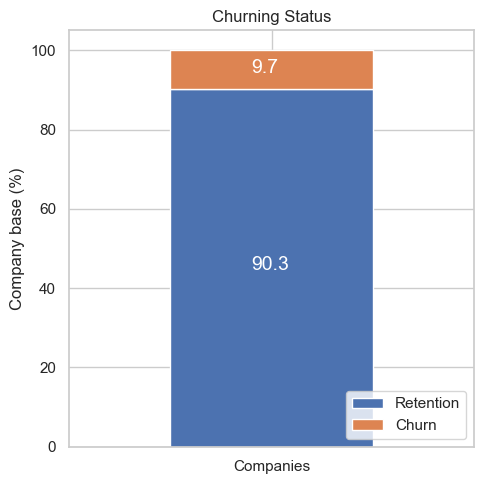

In [13]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_='upper right'):
    ax = dataframe.plot(kind='bar', stacked=True, figsize=size_, rot=rot_, title=title_)
    for p in ax.patches:
        value = str(round(p.get_height(), 1))
        if value == '0.0':
            continue
        ax.annotate(value,
                    ((p.get_x() + p.get_width() / 2) * 0.99 - 0.05,
                     (p.get_y() + p.get_height() / 2) * 0.99),
                    color='white', size=14)
    plt.legend(['Retention', 'Churn'], loc=legend_)
    plt.ylabel('Company base (%)')
    plt.tight_layout()
    plt.show()

churn = client_df[['id', 'churn']].copy()
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby('churn').count()
churn_pct   = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_pct.transpose(), 'Churning Status', (5, 5), legend_='lower right')

## 7. Categorical Column Distributions vs Churn

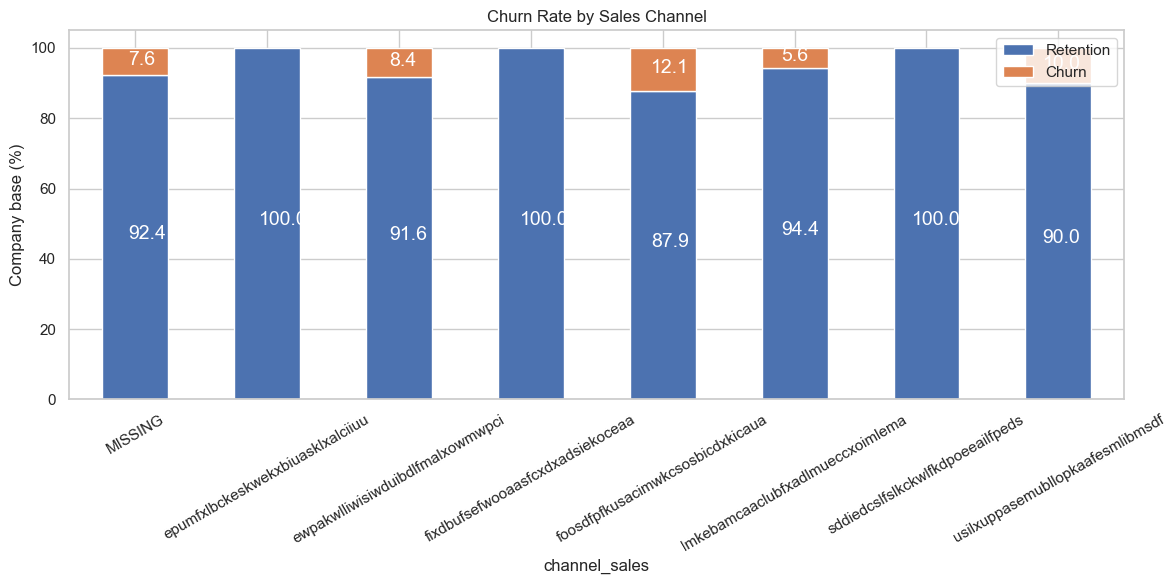

In [14]:
# Channel sales distribution vs churn
channel_churn = client_df.groupby(['channel_sales', 'churn']).size().unstack(fill_value=0)
channel_churn_pct = channel_churn.div(channel_churn.sum(axis=1), axis=0) * 100
plot_stacked_bars(channel_churn_pct, 'Churn Rate by Sales Channel', size_=(12, 6), rot_=30)

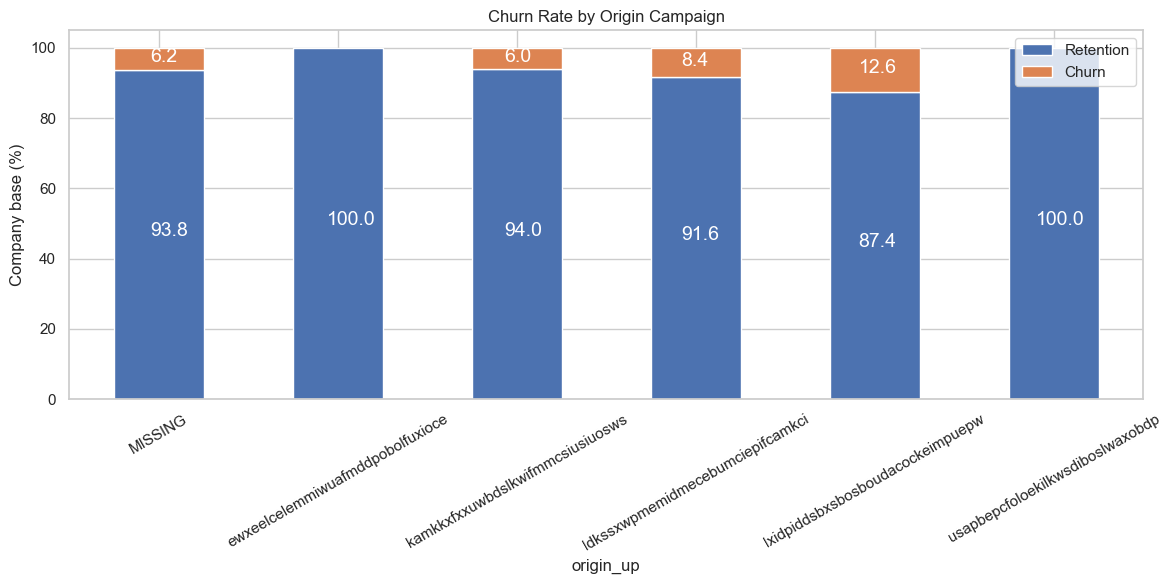

In [15]:
# Origin up distribution vs churn
origin_churn = client_df.groupby(['origin_up', 'churn']).size().unstack(fill_value=0)
origin_churn_pct = origin_churn.div(origin_churn.sum(axis=1), axis=0) * 100
plot_stacked_bars(origin_churn_pct, 'Churn Rate by Origin Campaign', size_=(12, 6), rot_=30)

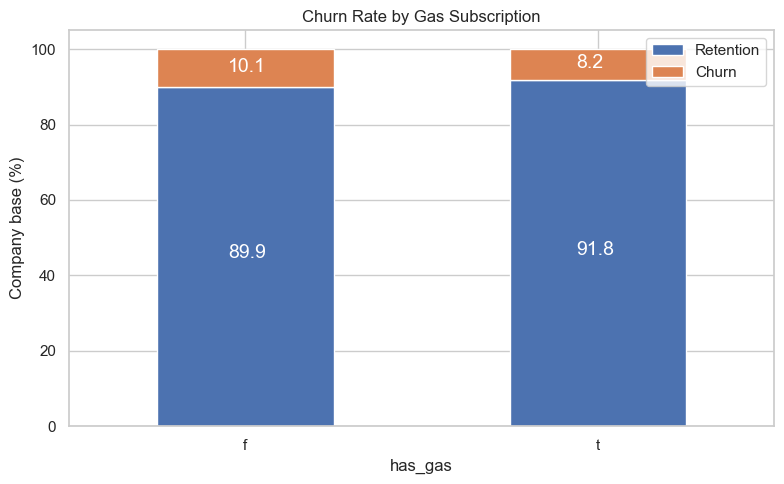

In [16]:
# has_gas distribution vs churn
gas_churn = client_df.groupby(['has_gas', 'churn']).size().unstack(fill_value=0)
gas_churn_pct = gas_churn.div(gas_churn.sum(axis=1), axis=0) * 100
plot_stacked_bars(gas_churn_pct, 'Churn Rate by Gas Subscription', size_=(8, 5))

## 8. Numeric Column Distributions

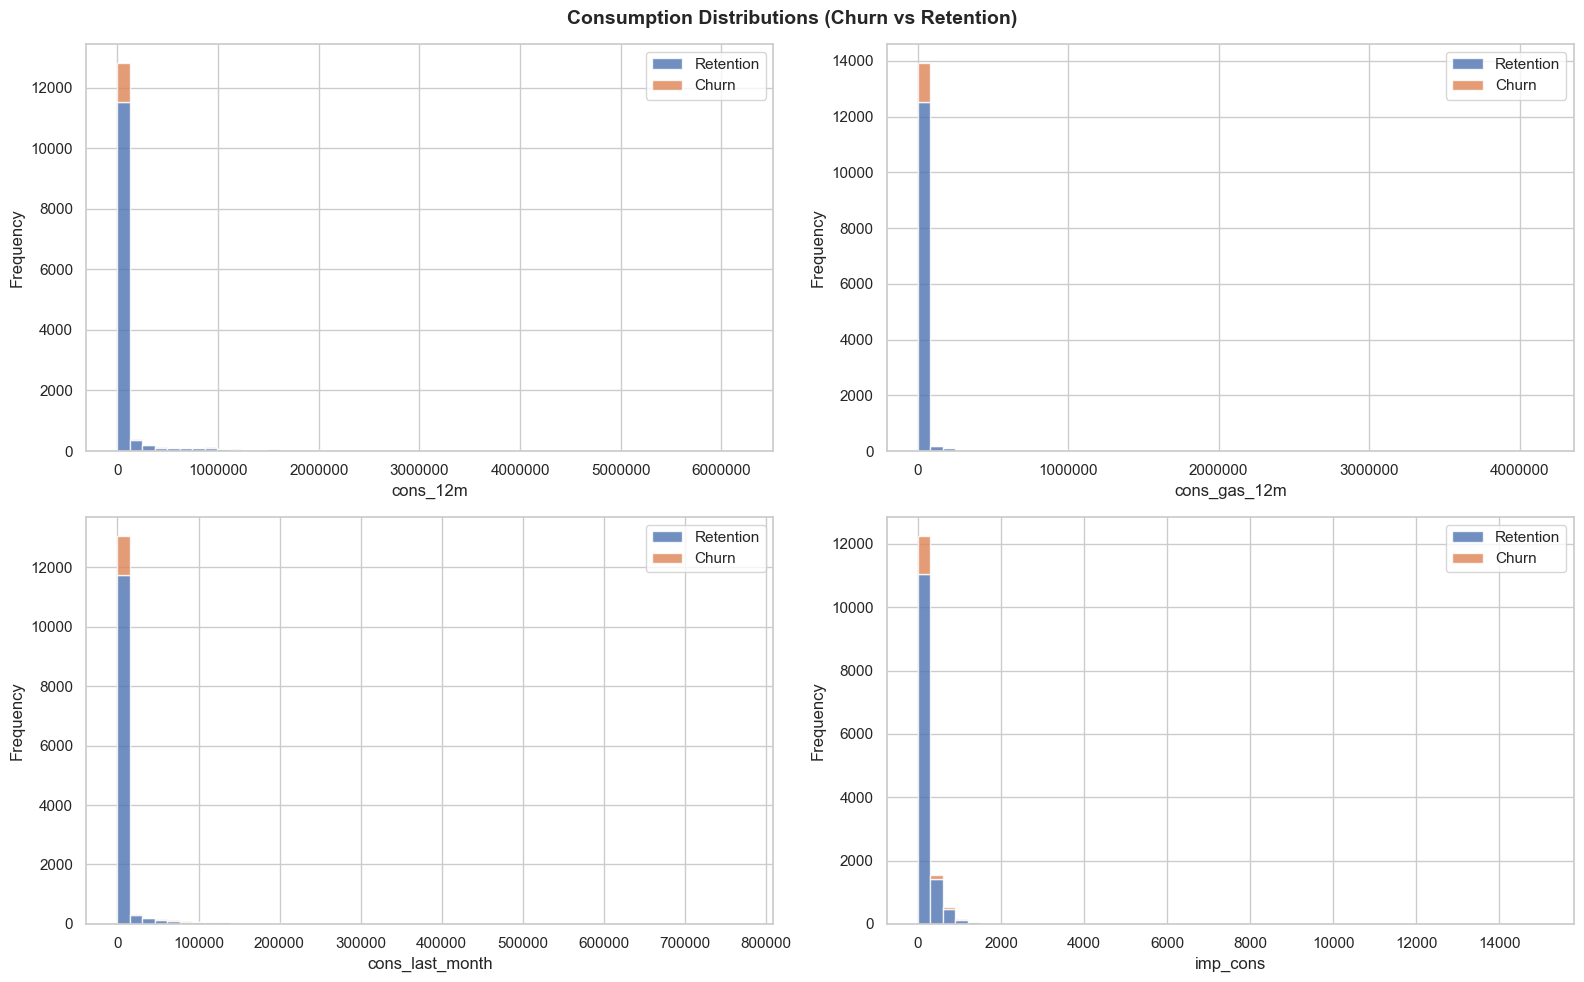

In [17]:
def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({
        'Retention': dataframe[dataframe['churn'] == 0][column],
        'Churn':     dataframe[dataframe['churn'] == 1][column]
    })
    temp[['Retention', 'Churn']].plot(kind='hist', bins=bins_, ax=ax, stacked=True, alpha=0.8)
    ax.set_xlabel(column)
    ax.ticklabel_format(style='plain', axis='x')

# Consumption columns
consumption_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axs = axs.flatten()
for i, col in enumerate(consumption_cols):
    plot_distribution(client_df, col, axs[i])
fig.suptitle('Consumption Distributions (Churn vs Retention)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

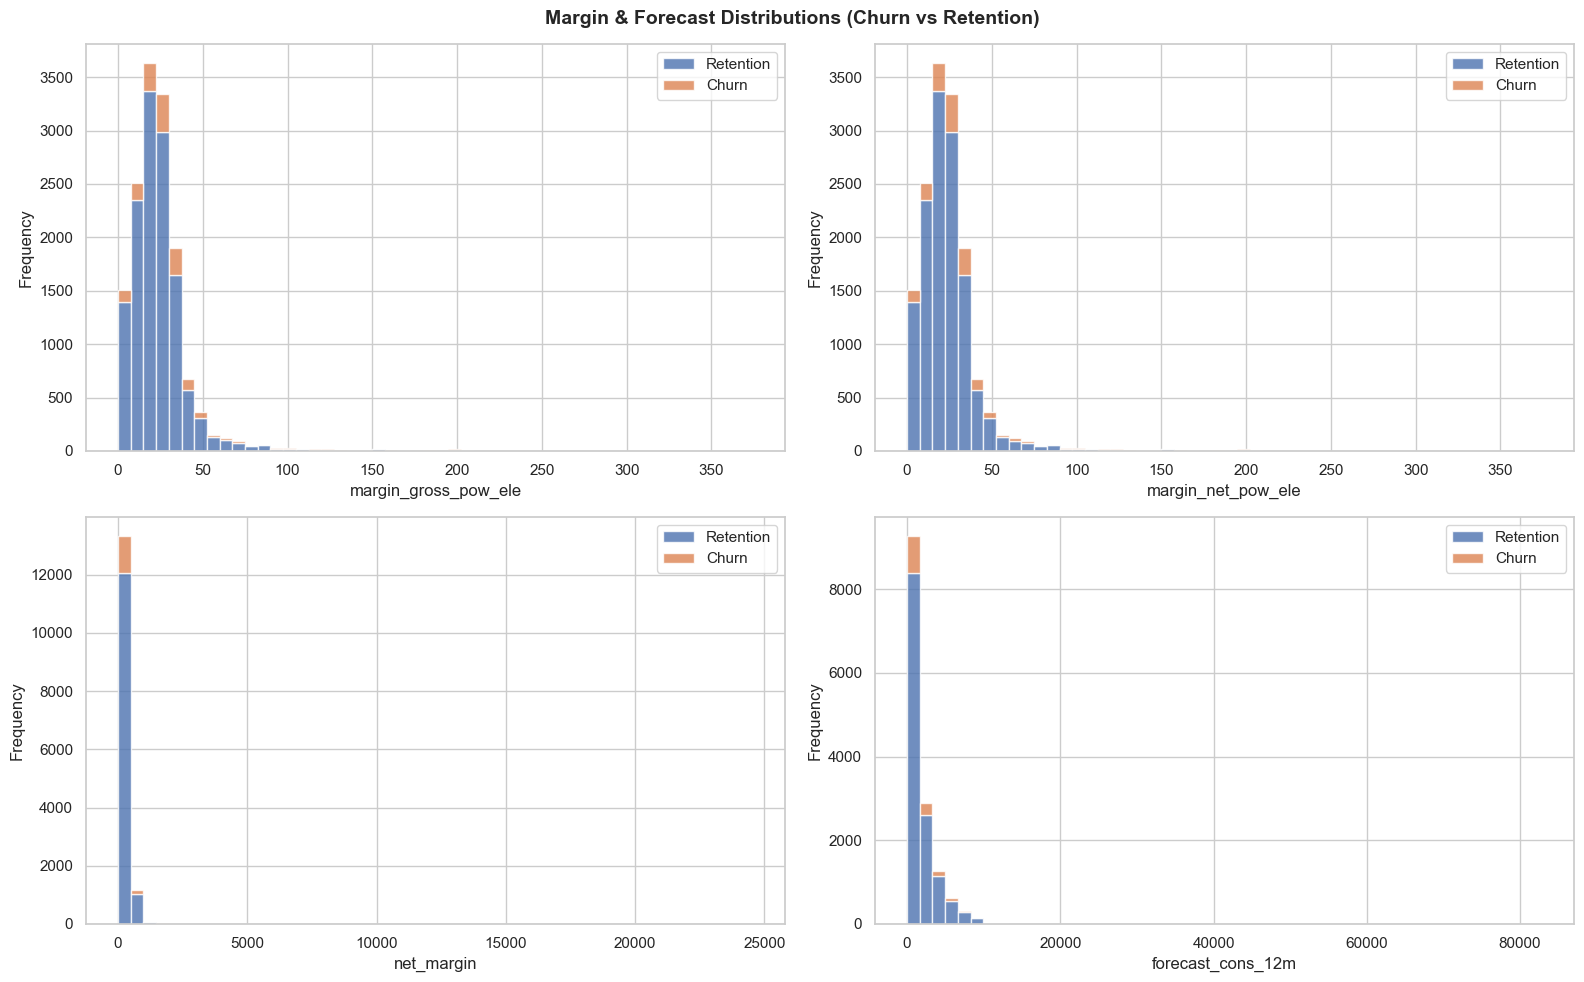

In [18]:
# Margin & forecast columns
margin_cols = ['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin', 'forecast_cons_12m']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axs = axs.flatten()
for i, col in enumerate(margin_cols):
    plot_distribution(client_df, col, axs[i])
fig.suptitle('Margin & Forecast Distributions (Churn vs Retention)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

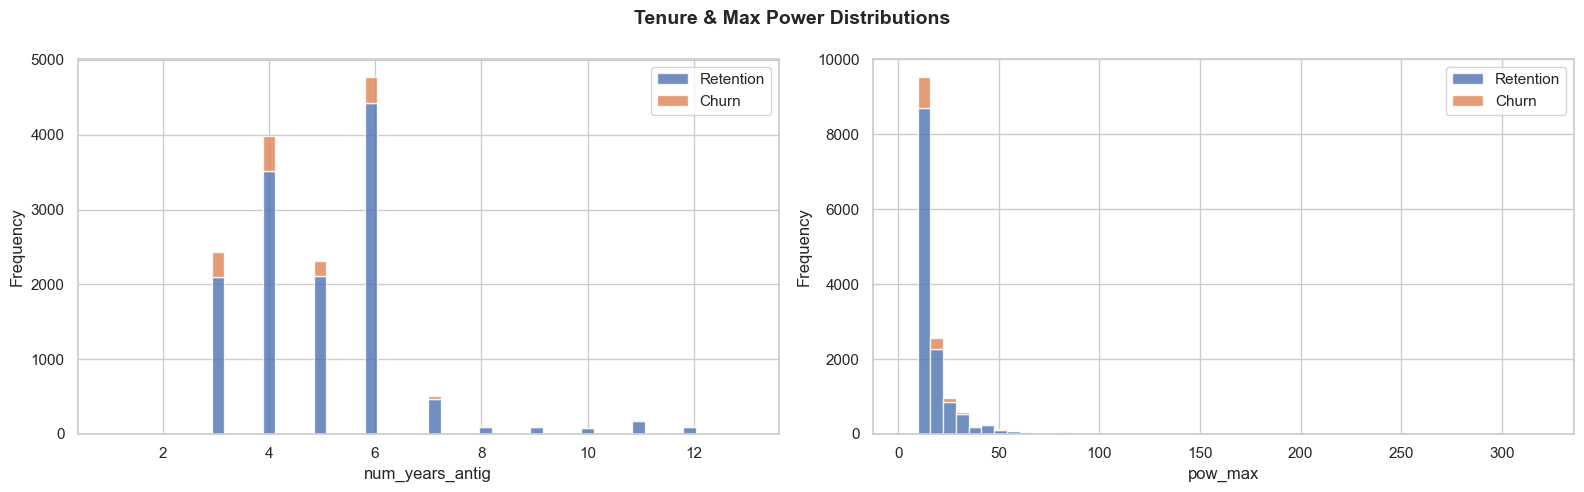

In [19]:
# Customer tenure & activity
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
plot_distribution(client_df, 'num_years_antig', axs[0])
plot_distribution(client_df, 'pow_max', axs[1])
fig.suptitle('Tenure & Max Power Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Price Data Distributions

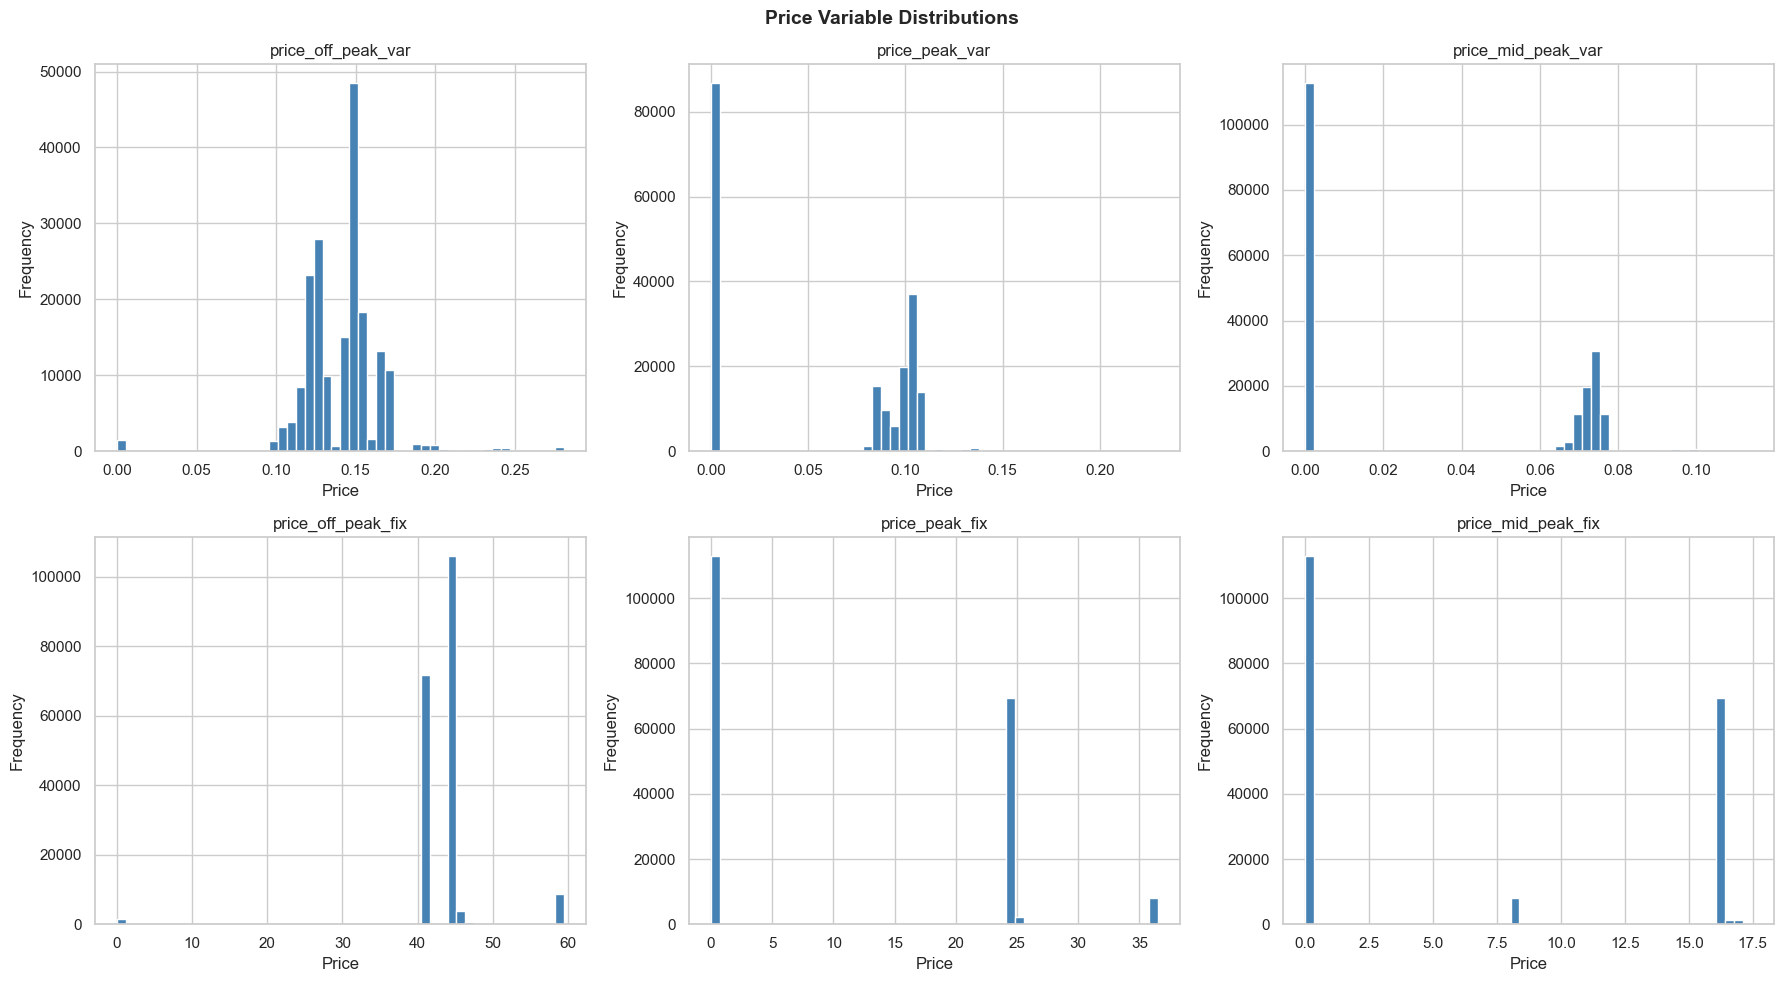

In [20]:
price_value_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
                    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axs = axs.flatten()
for i, col in enumerate(price_value_cols):
    axs[i].hist(price_df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axs[i].set_title(col)
    axs[i].set_xlabel('Price')
    axs[i].set_ylabel('Frequency')
    axs[i].ticklabel_format(style='plain', axis='x')
fig.suptitle('Price Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

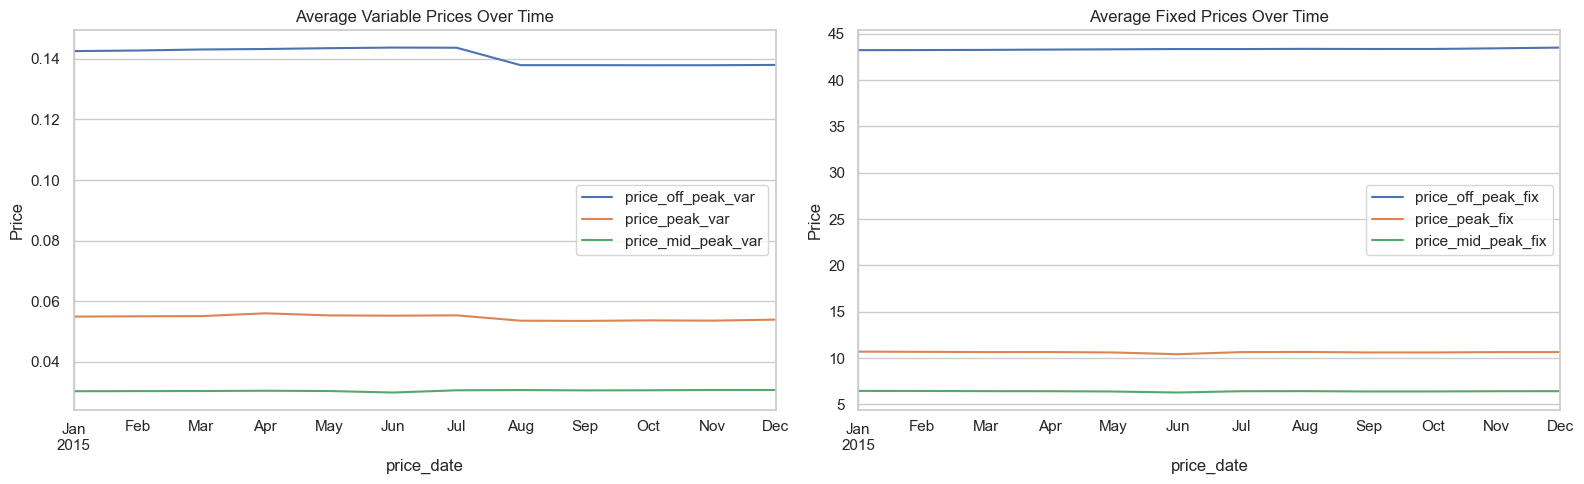

In [21]:
# Average price over time
price_over_time = price_df.groupby('price_date')[price_value_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_over_time[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']].plot(ax=axes[0])
axes[0].set_title('Average Variable Prices Over Time')
axes[0].set_ylabel('Price')

price_over_time[['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']].plot(ax=axes[1])
axes[1].set_title('Average Fixed Prices Over Time')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

## 10. Correlation Analysis (Client Data)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


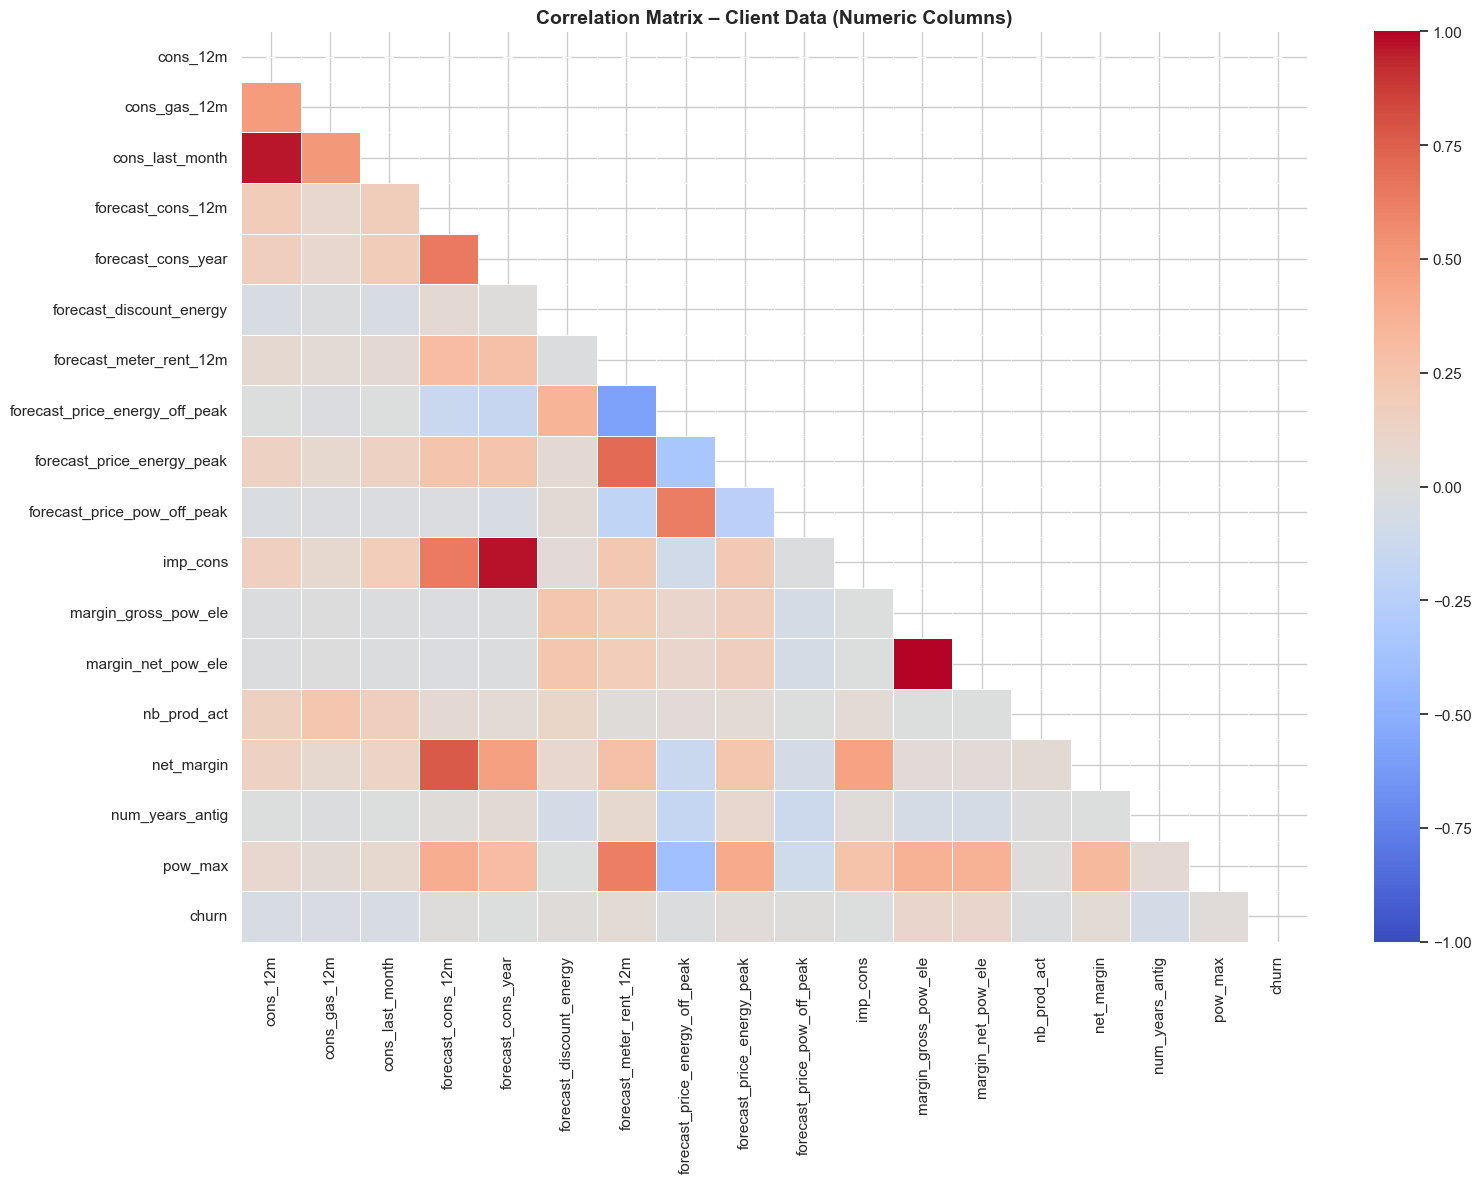

In [22]:
numeric_cols = client_df.select_dtypes(include=[np.number]).columns.tolist()
corr = client_df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix – Client Data (Numeric Columns)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

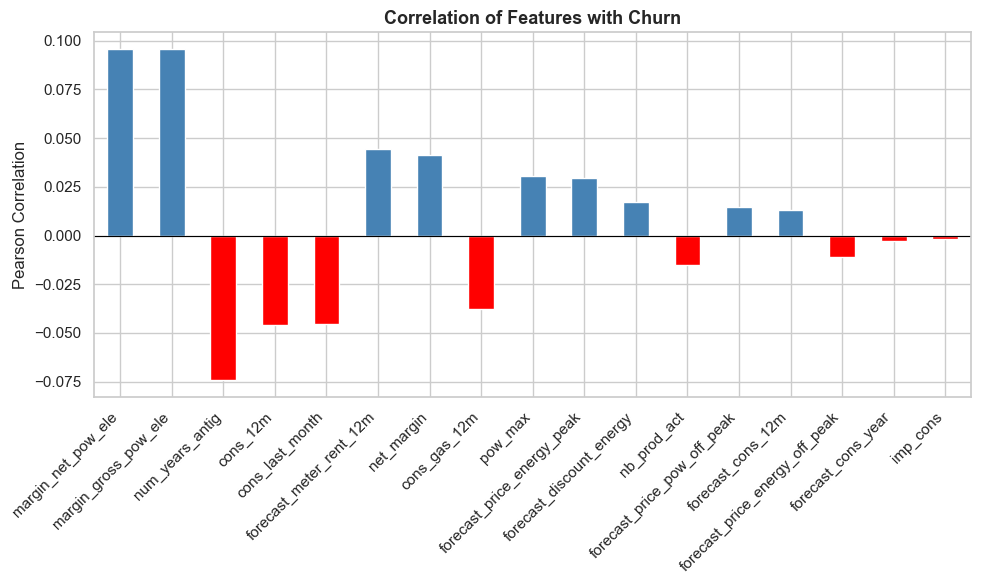

In [23]:
# Correlation with churn specifically
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
plt.figure(figsize=(10, 6))
churn_corr.plot(kind='bar', color=['red' if x < 0 else 'steelblue' for x in churn_corr])
plt.title('Correlation of Features with Churn', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Churn rate** | ~9.7% of the customer base has churned – an imbalanced dataset |
| **Date columns** | Stored as strings; must be converted to `datetime` for feature engineering |
| **Consumption** | Highly right-skewed; a small number of customers consume vastly more energy |
| **Gas usage** | Most customers do not use gas (`cons_gas_12m` = 0 for 75%+) |
| **Price peaks** | `price_peak_var` and `price_mid_peak_var` are 0 for most customers – off-peak pricing dominates |
| **Channel sales** | Certain channels show notably higher churn rates |
| **Tenure** | `num_years_antig` shows some correlation with churn – newer customers may churn more |
| **Margins** | Both gross and net power margins show weak correlation with churn |
| **No missing values** | Both datasets are complete – no imputation required |
